In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("car_prediction_data.csv")


In [3]:
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [6]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

In [7]:
df["Car_Name"].unique()

array(['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza',
       's cross', 'alto 800', 'ertiga', 'dzire', 'alto k10', 'ignis',
       '800', 'baleno', 'omni', 'fortuner', 'innova', 'corolla altis',
       'etios cross', 'etios g', 'etios liva', 'corolla', 'etios gd',
       'camry', 'land cruiser', 'Royal Enfield Thunder 500',
       'UM Renegade Mojave', 'KTM RC200', 'Bajaj Dominar 400',
       'Royal Enfield Classic 350', 'KTM RC390', 'Hyosung GT250R',
       'Royal Enfield Thunder 350', 'KTM 390 Duke ',
       'Mahindra Mojo XT300', 'Bajaj Pulsar RS200',
       'Royal Enfield Bullet 350', 'Royal Enfield Classic 500',
       'Bajaj Avenger 220', 'Bajaj Avenger 150', 'Honda CB Hornet 160R',
       'Yamaha FZ S V 2.0', 'Yamaha FZ 16', 'TVS Apache RTR 160',
       'Bajaj Pulsar 150', 'Honda CBR 150', 'Hero Extreme',
       'Bajaj Avenger 220 dtsi', 'Bajaj Avenger 150 street',
       'Yamaha FZ  v 2.0', 'Bajaj Pulsar  NS 200', 'Bajaj Pulsar 220 F',
       'TVS Apache RTR 180', 

In [8]:
df["Fuel_Type"].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [9]:
df["Seller_Type"].unique()

array(['Dealer', 'Individual'], dtype=object)

In [10]:
df["Transmission"].unique()

array(['Manual', 'Automatic'], dtype=object)

In [11]:
#extract brand name from  car_name
df["Brand"]=df["Car_Name"].apply(lambda x:x.split()[0])

In [12]:
print(df["Brand"].nunique())
print(df["Brand"].value_counts())

44
Brand
city        26
Bajaj       25
Royal       17
corolla     17
Honda       17
Hero        15
verna       14
etios       11
fortuner    11
brio        10
innova       9
ciaz         9
i20          9
Yamaha       8
TVS          8
grand        8
amaze        7
jazz         7
eon          6
ertiga       6
alto         6
sx4          6
i10          5
swift        5
ritz         4
KTM          4
wagon        4
dzire        4
Activa       3
creta        3
xcent        3
elantra      2
ignis        1
vitara       1
s            1
Mahindra     1
Hyosung      1
baleno       1
omni         1
Suzuki       1
camry        1
land         1
UM           1
800          1
Name: count, dtype: int64


In [13]:
df.drop("Car_Name",axis=1,inplace=True)

In [14]:
#for other categorical data
pd.get_dummies(df["Fuel_Type"],drop_first=True)

,Diesel,Petrol
0,False,True
1,True,False
2,False,True
3,False,True
4,True,False
...,...,...
296,True,False
297,False,True
298,False,True
299,True,False


In [15]:

pd.get_dummies(df["Seller_Type"],drop_first=True)

,Individual
0,False
1,False
2,False
3,False
4,False
...,...
296,False
297,False
298,False
299,False


In [16]:

pd.get_dummies(df["Transmission"],drop_first=True)

,Manual
0,True
1,True
2,True
3,True
4,True
...,...
296,True
297,True
298,True
299,True


In [17]:
df.columns

Index(['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'Brand'],
      dtype='object')

In [18]:
df.dtypes

Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
Brand             object
dtype: object

In [19]:
#car age feature
df["Car_Age"]=2026-df["Year"]
df.drop("Year",axis =1,inplace=True)

In [20]:
df=pd.get_dummies(
    df,
    columns=["Fuel_Type","Seller_Type","Transmission","Brand"],
    drop_first=True
)

In [21]:
print(df.head())

   Selling_Price  Present_Price  Kms_Driven  Owner  Car_Age  Fuel_Type_Diesel  \
0           3.35           5.59       27000      0       12             False   
1           4.75           9.54       43000      0       13              True   
2           7.25           9.85        6900      0        9             False   
3           2.85           4.15        5200      0       15             False   
4           4.60           6.87       42450      0       12              True   

   Fuel_Type_Petrol  Seller_Type_Individual  Transmission_Manual  \
0              True                   False                 True   
1             False                   False                 True   
2              True                   False                 True   
3              True                   False                 True   
4             False                   False                 True   

   Brand_Activa  ...  Brand_land  Brand_omni  Brand_ritz  Brand_s  \
0         False  ...       False   

In [22]:
y= df["Selling_Price"]
x=df.drop("Selling_Price",axis=1)

In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [25]:
y_pred = model.predict(x_test)

In [26]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 SCORE:",r2_score(y_test,y_pred))

MAE: 0.6151803278688528
RMSE: 0.9033472456533581
R2 SCORE: 0.9645749711490618


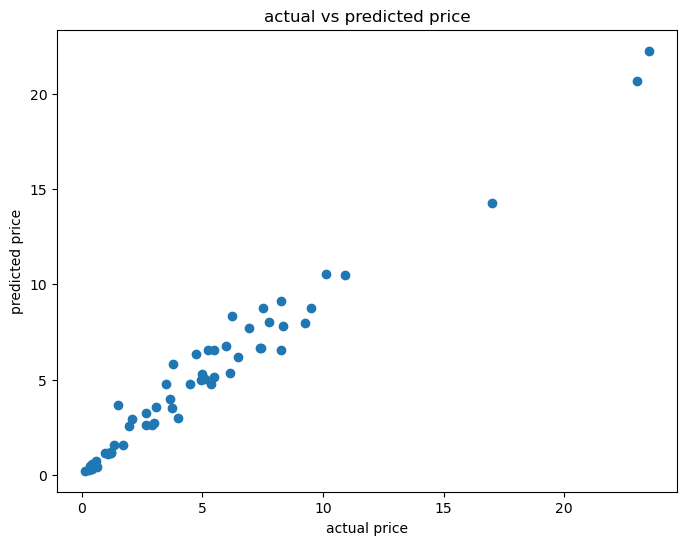

In [27]:
#actual vs predicted graph
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("actual price")
plt.ylabel('predicted price')
plt.title("actual vs predicted price")
plt.show()

In [29]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                   Feature    Importance
0            Present_Price  8.663411e-01
3                  Car_Age  5.961777e-02
1               Kms_Driven  3.456635e-02
7      Transmission_Manual  8.192998e-03
34          Brand_fortuner  5.974871e-03
41              Brand_land  5.526124e-03
39            Brand_innova  3.337652e-03
26              Brand_city  3.319457e-03
5         Fuel_Type_Petrol  2.999894e-03
6   Seller_Type_Individual  2.247507e-03
27           Brand_corolla  2.220710e-03
4         Fuel_Type_Diesel  1.466367e-03
2                    Owner  9.582477e-04
28             Brand_creta  7.356635e-04
47             Brand_verna  6.147499e-04
30           Brand_elantra  3.857897e-04
33             Brand_etios  2.758373e-04
40              Brand_jazz  2.700223e-04
25              Brand_ciaz  2.520389e-04
21             Brand_amaze  1.431293e-04
20              Brand_alto  1.278243e-04
37               Brand_i20  6.730217e-05
23              Brand_brio  5.371176e-05
31              

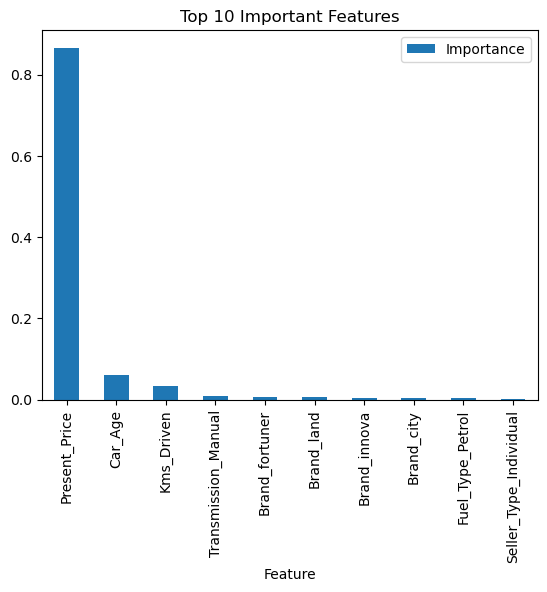

In [30]:
feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title("Top 10 Important Features")
plt.show()

In [ ]:
#the model is relying heavily on present price